# <center> Machine Learning in Computational Biology - Term Project </center>

## <center> Task B.4 </center>

### <center> Model Evaluation - Balanced LOPO at Patient Level with Shared Preprocessing - No Hyperparameter Tuning </center>
---

# Libraries & Paths

In [1]:
# Libraries, paths and fixed settings
import gc
import json
import os
import random
import sys
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse as sp
import xgboost as xgb

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
##############################################################################
SRC_DIR = Path("../src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from helper_functions import (calculate_metrics, make_sample_balanced_class_weights,)
from feature_builders import (GenesBuilder,PathwaysBuilder,GenesPathwaysBuilder, PCABuilder, MIBuilder,RFEPCBuilder)

##############################################################################
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings("ignore")
##############################################################################
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
FIGURES_DIR = Path("../figures")
RESULTS_DIR = OUTPUT_DIR / "task_b_lopo_no_tuning"
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FIGURES_DIR.mkdir( parents=True,exist_ok=True)
RESULTS_DIR.mkdir(parents=True,exist_ok=True)
H5AD_FILE = (OUTPUT_DIR / "filtered_anndata_pathways.h5ad")

##############################################################################
#  Values -->  Predefined and kept fixed throughout the analysis.
N_PCA_COMPONENTS = 20
MI_K = 500
RFE_N_FEATURES = 10

##############################################################################
RUN_ID = "taskb_shared_preprocessing_patient_score_fixed_v6"
print("Input:", H5AD_FILE)
print("Results:", RESULTS_DIR)


Input: ..\outputs\filtered_anndata_pathways.h5ad
Results: ..\outputs\task_b_lopo_no_tuning


##  Loading the AnnData object

In [2]:
# Loading the AnnData 

if not H5AD_FILE.exists():
    raise FileNotFoundError( f"{H5AD_FILE} was not found.")


adata = ad.read_h5ad(H5AD_FILE)


# Checking requiring metadata 
required_obs_columns = {"patient_id","patient_timepoint",}
missing_required = ( required_obs_columns - set(adata.obs.columns))
if missing_required:
    raise KeyError(f"Missing required adata.obs columns: {sorted(missing_required)}")


# Detecting the response column used for modeling & the available PROGENy pathway features
if "response_label" in adata.obs.columns:
    response_column = "response_label"

elif "response" in adata.obs.columns:
    response_column = "response"

else:
    raise KeyError("Neither exists in adata.obs.")


pathway_cols = [str(column) for column in adata.obs.columns if str(column).lower().startswith("progeny_")]

if not pathway_cols:
    raise ValueError("No PROGENy pathway columns were found in adata.obs.")

In [3]:
n_cells = adata.n_obs
n_genes = adata.n_vars
n_patients = adata.obs["patient_id"].nunique()
n_samples = adata.obs["patient_timepoint"].nunique()
n_pathways = len(pathway_cols)

print("Summary")
print(f"Cells : {n_cells:,}")
print(f"Genes : {n_genes:,}")
print(f"Patients: {n_patients}")
print(f"Biological samples: {n_samples}")
print(f"PROGENy pathways: {n_pathways}")
print(f"Response column: {response_column}")

print("\nResponse distribution:")
print(adata.obs[response_column].value_counts(dropna=False))

Summary
Cells : 16,291
Genes : 10,019
Patients: 32
Biological samples: 48
PROGENy pathways: 14
Response column: response_label

Response distribution:
response_label
Non-responder    10727
Responder         5564
Name: count, dtype: int64


## Create modelling arrays

- `patient_id` is used as the grouping variable for patient-level LOPO.
- `patient_timepoint` is used as the biological sample identifier.
- The column `sample` is not used as the biological sample ID.

In [4]:
# Gene handling
X_genes = adata.X
if sp.issparse(X_genes):
    X_genes = X_genes.tocsr().astype(np.float32)
else:
    X_genes = np.asarray(X_genes, dtype=np.float32)


# PROGENy pathway scores part
X_pathways = (adata.obs[pathway_cols].to_numpy(dtype=np.float32))

# Binary response used as the prediction target. Reminding: 1 = responder, 0 = non-responder.
y = adata.obs["response"].to_numpy(dtype=np.int8)

groups = (adata.obs["patient_id"].astype(str).to_numpy()) # patient_id --> defines the groups used for patient-level LOPO.
sample_ids = (adata.obs["patient_timepoint"].astype(str).to_numpy()) # patient_timepoint --> biological sample.
gene_names = np.asarray(adata.var_names.astype(str))


# Sanity check that the prediction target is correctly encoded.
if not set(np.unique(y)).issubset({0, 1}):
    raise ValueError("The response target must contain only 0 and 1.")


---
## Define matched ablation conditions

In [5]:
CONDITIONS = {"A_Genes": lambda: GenesBuilder(),
              "B_Pathways": lambda: PathwaysBuilder(),
              "C_Genes_Pathways": lambda: GenesPathwaysBuilder(),
              "D_PCA": lambda: PCABuilder(n_components=N_PCA_COMPONENTS,add_pathways=False),
              "E_PCA_Pathways": lambda: PCABuilder(n_components=N_PCA_COMPONENTS,add_pathways=True),
              "F_MI_Genes": lambda: MIBuilder(k=MI_K, add_pathways=False),
              "G_MI_Genes_Pathways": lambda: MIBuilder( k=MI_K,add_pathways=True),
              "H_RFE_PCA": lambda: RFEPCBuilder(n_pcs=N_PCA_COMPONENTS,n_features=RFE_N_FEATURES,add_pathways=False),
              "I_RFE_PCA_Pathways": lambda: RFEPCBuilder(n_pcs=N_PCA_COMPONENTS,n_features=RFE_N_FEATURES,add_pathways=True),
              }

CONDITIONS_TO_RUN = list(CONDITIONS)

print("Conditions:")
for condition_name in CONDITIONS_TO_RUN:
    print(" -", condition_name)

Conditions:
 - A_Genes
 - B_Pathways
 - C_Genes_Pathways
 - D_PCA
 - E_PCA_Pathways
 - F_MI_Genes
 - G_MI_Genes_Pathways
 - H_RFE_PCA
 - I_RFE_PCA_Pathways


## Fixed model parameters and balanced training


In [6]:

MODEL_PARAMS = {"XGBoost": {"n_estimators": 200,"max_depth": 6,
                            "learning_rate": 0.05,"subsample": 0.8,"eval_metric": "auc",
                            "random_state": SEED, "n_jobs": -1},

                "LogisticRegression": {"penalty": "l2", "solver": "lbfgs",
                                       "max_iter": 1000,"class_weight": None,
                                       "random_state": SEED},

                "RandomForest": {"n_estimators": 100, "max_depth": 9,
                                 "min_samples_split": 5, "class_weight": None,
                                 "random_state": SEED,"n_jobs": -1}}


In [7]:
MODELS_TO_RUN = ["LogisticRegression","XGBoost","RandomForest"]

print("Models to run:")

for model_name in MODELS_TO_RUN:
    print(" -", model_name)

Models to run:
 - LogisticRegression
 - XGBoost
 - RandomForest


In [8]:
# Creating each classifier by using the predefined fixed parameters.

def build_fixed_model(model_name: str):

    if model_name not in MODEL_PARAMS:
        raise ValueError(f"Unknown model_name: {model_name}. Available models: {list(MODEL_PARAMS)}")

    params = MODEL_PARAMS[model_name].copy()

    if model_name == "LogisticRegression":
        return LogisticRegression(**params)

    if model_name == "RandomForest":
        return RandomForestClassifier(**params)

    if model_name == "XGBoost":
        return xgb.XGBClassifier(**params)

    raise ValueError(f"Unsupported model: {model_name}")

In [9]:
# Summarizing primary and secondary evaluation metrics for one model-condition combination.

def _summarize_model_predictions(model_name: str, condition_name: str, sample_predictions: pd.DataFrame,
                                 patient_predictions: pd.DataFrame,) -> dict:

    primary_sample_metrics = calculate_metrics(predictions=sample_predictions,level="sample")
    non_mixed_patient_ids = set(patient_predictions.loc[~patient_predictions["mixed_response"], "patient_id"].astype(str))
    non_mixed_sample_predictions = sample_predictions.loc[sample_predictions["patient_id"].astype(str)
                                                          .isin(non_mixed_patient_ids)].copy()
    valid_patient_predictions = patient_predictions.loc[~patient_predictions["mixed_response"]].copy()
    secondary_sample_metrics = calculate_metrics(predictions=non_mixed_sample_predictions,level="sample")
    secondary_patient_metrics = calculate_metrics(predictions=valid_patient_predictions,level="patient")

    return {
        "Model": model_name,
        "Condition": condition_name,
        "Primary_Sample_AUC_All": primary_sample_metrics["AUC"],
        "Primary_Sample_Average_precision_All": primary_sample_metrics["Average_precision"],
        "Primary_Sample_Balanced_accuracy_All": primary_sample_metrics["Balanced_accuracy"],
        "Primary_Sample_Accuracy_All": primary_sample_metrics["Accuracy"],
        "Primary_Sample_Sensitivity_All": primary_sample_metrics["Sensitivity"],
        "Primary_Sample_Specificity_All": primary_sample_metrics["Specificity"],
        "Primary_Sample_Precision_All": primary_sample_metrics["Precision"],
        "Primary_Sample_F1_All": primary_sample_metrics["F1"],
        "Primary_Sample_MCC_All": primary_sample_metrics["MCC"],
        "Secondary_Sample_AUC_NonMixed": secondary_sample_metrics["AUC"],
        "Secondary_Patient_AUC_NonMixed": secondary_patient_metrics["AUC"],
        "N_samples_all": int(len(sample_predictions)),
        "N_samples_nonmixed": int(len(non_mixed_sample_predictions)),
        "N_patients_all": int(len(patient_predictions)),
        "N_patients_nonmixed": int(len(valid_patient_predictions)),
        "N_patients_mixed": int(patient_predictions["mixed_response"].sum()),
        "Mean_n_features": float(patient_predictions["n_features"].mean()),
        "Balancing": "equal sample total weight + balanced sample-level classes"
        }

In [10]:
# Running one feature condition across all models using the same LOPO folds
# and the same fold-specific preprocessing.

def run_condition_all_models(condition_name: str,builder_factory,model_names,verbose: bool = True):
    model_names = list(model_names)

    unknown_models = [name for name in model_names if name not in MODEL_PARAMS]

    if unknown_models:
        raise ValueError(f"Unknown models: {unknown_models} Available models: {list(MODEL_PARAMS)}")

    groups_array = np.asarray(groups).astype(str)
    sample_ids_array = np.asarray(sample_ids).astype(str)
    y_array = np.asarray(y, dtype=int)
    n_observations = len(y_array)

    # Checking that all modelling arrays refer to the same cells.
    if len(groups_array) != n_observations:
        raise ValueError("groups and y have different lengths.")
    if len(sample_ids_array) != n_observations:
        raise ValueError("sample_ids and y have different lengths.")
    if X_genes.shape[0] != n_observations:
        raise ValueError("X_genes and y have different row counts.")
    if X_pathways.shape[0] != n_observations:
        raise ValueError("X_pathways and y have different row counts.")

    # Creating the patient-level LOPO splits.
    logo = LeaveOneGroupOut()
    splits = list(logo.split(X=np.zeros(n_observations),y=y_array,groups=groups_array))

    sample_rows_by_model = {model_name: [] for model_name in model_names}
    patient_rows_by_model = { model_name: [] for model_name in model_names}

    selected_feature_outputs = []
    leakage_outputs = []

    for fold_number, (train_idx, test_idx) in enumerate(splits,start=1):
        train_patients = np.unique(groups_array[train_idx]).astype(str)
        test_patients = np.unique(groups_array[test_idx]).astype(str)

        if len(test_patients) != 1:
            raise ValueError(
                f"Fold {fold_number} contains {len(test_patients)} held-out patients instead of one.")

        held_out_patient = test_patients[0]
        train_sample_ids = sample_ids_array[train_idx]
        test_sample_ids = sample_ids_array[test_idx]

        # Checking that patients and samples do not overlap across the fold.
        patient_overlap = set(train_patients) & set(test_patients)
        sample_overlap = set(train_sample_ids) & set(test_sample_ids)

        leakage_outputs.append(
            {"condition": condition_name,
             "fold": fold_number,
             "held_out_patient": held_out_patient,
             "patient_overlap_count": len(patient_overlap),
             "sample_overlap_count": len(sample_overlap),
             "train_patients": len(train_patients),
             "test_patients": len(test_patients),
             "train_samples": len(np.unique(train_sample_ids)),
             "test_samples": len(np.unique(test_sample_ids)),
             "train_cells": len(train_idx),
             "test_cells": len(test_idx)
            })

        if patient_overlap:
            raise ValueError(f"Patient leakage in fold {fold_number}: {sorted(patient_overlap)}")

        if sample_overlap:
            raise ValueError(f"Sample leakage in fold {fold_number}: {sorted(sample_overlap)}")

        y_train = y_array[train_idx]
        y_test = y_array[test_idx]

        if np.unique(y_train).size < 2:
            raise ValueError(f"Fold {fold_number} training data contains one class.")

        # Fitting feature engineering only on the training fold.
        builder = builder_factory()

        builder.fit(genes=X_genes[train_idx], pathways=X_pathways[train_idx], y=y_train, group_ids=train_sample_ids)
        X_train = builder.transform( genes=X_genes[train_idx],pathways=X_pathways[train_idx])
        X_test = builder.transform(genes=X_genes[test_idx],pathways=X_pathways[test_idx])
        feature_names = builder.get_feature_names(gene_names=gene_names,pathway_names=pathway_cols)

        if X_train.shape[1] != X_test.shape[1]:
            raise ValueError(f"Train/test feature mismatch in fold {fold_number}: {X_train.shape[1]} vs {X_test.shape[1]}.")

        if X_train.shape[1] != len(feature_names):
            raise ValueError(f"Feature-name mismatch in fold {fold_number}: {X_train.shape[1]} columns vs {len(feature_names)} names.")

        # Fitting scaling only on the training fold.
        if sp.issparse(X_train):
            scaler = StandardScaler(with_mean=False)
        else:
            scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Calculating fold-specific training weights.
        training_weights = make_sample_balanced_class_weights(training_sample_ids=train_sample_ids,training_labels=y_train)

        selected_feature_outputs.append(pd.DataFrame({"condition": condition_name,"fold": fold_number,
                                                      "held_out_patient": held_out_patient,
                                                      "feature": feature_names}))

        # Fitting all classifiers using the same prepared fold data.
        for model_name in model_names:
            model = build_fixed_model(model_name=model_name)
            model.fit(X_train_scaled,y_train,sample_weight=training_weights)
            cell_probabilities = model.predict_proba(X_test_scaled)[:, 1]

            if not np.isfinite(cell_probabilities).all():
                raise ValueError(f"Non-finite probabilities for {model_name}condition {condition_name}, fold {fold_number}.")

            # Aggregating cell probabilities to biological samples.
            fold_sample_rows = []

            for current_sample in np.sort(pd.unique(test_sample_ids)):
                sample_mask = (test_sample_ids == current_sample)
                labels_in_sample = np.unique(y_test[sample_mask])

                if len(labels_in_sample) != 1:
                    raise ValueError(
                        f"Sample {current_sample} has multiple response labels: {labels_in_sample}")

                sample_score = float(cell_probabilities[sample_mask].mean())

                row = {
                    "model": model_name,
                    "condition": condition_name,
                    "fold": fold_number,
                    "patient_id": held_out_patient,
                    "sample_id": str(current_sample),
                    "true_label": int(labels_in_sample[0]),
                    "sample_score": sample_score,
                    "predicted_label": int(sample_score >= 0.5),
                    "n_cells": int(sample_mask.sum()),
                    "n_features": int(X_train_scaled.shape[1]),
                }

                sample_rows_by_model[model_name].append(row)
                fold_sample_rows.append(row)

            fold_sample_frame = pd.DataFrame(fold_sample_rows)
            unique_patient_labels = np.sort(fold_sample_frame["true_label"].dropna().unique())

            # Reminding : A patient is non-mixed only when all samples have the same response label.
            same_response_across_samples = (len(unique_patient_labels) == 1)
            mixed_response = (not same_response_across_samples)

            if same_response_across_samples:
                patient_true_label = int(unique_patient_labels[0])

                # Giving equal weight to each biological sample.
                patient_score = float(fold_sample_frame["sample_score"].mean())
                patient_predicted_label = int(patient_score >= 0.5)

            else:
                patient_true_label = np.nan
                patient_score = np.nan
                patient_predicted_label = np.nan

            patient_rows_by_model[model_name].append(
                {
                    "model": model_name,
                    "condition": condition_name,
                    "fold": fold_number,
                    "patient_id": held_out_patient,
                    "true_label": patient_true_label,
                    "patient_score": patient_score,
                    "predicted_label": patient_predicted_label,
                    "mixed_response": bool(mixed_response),
                    "response_values": ",".join(map( str, unique_patient_labels.tolist())),
                    "n_cells": int(len(test_idx)),
                    "n_samples": int(len(fold_sample_frame)),
                    "n_features": int(X_train_scaled.shape[1]),
                }
            )

            if verbose:
                response_text = ("mixed" if mixed_response else ("R" if patient_true_label == 1 else "NR"))
                score_text = ("NA" if mixed_response else f"{patient_score:.3f}")

                print(
                    f"{condition_name} | "
                    f"Fold {fold_number:02d}/{len(splits):02d} | "
                    f"{model_name} | "
                    f"Patient={held_out_patient} | "
                    f"Response={response_text} | "
                    f"Patient score={score_text} | "
                    f"Sample labels={unique_patient_labels.tolist()} | "
                    f"Samples={len(fold_sample_frame)} | "
                    f"Cells={len(test_idx)} | "
                    f"Features={X_train_scaled.shape[1]}"
                )

            del model, cell_probabilities

        del (X_train,X_test,X_train_scaled,X_test_scaled,builder,scaler,training_weights)
        gc.collect()

    # Combining the feature-selection and leakage information from all folds.
    selected_features = pd.concat(selected_feature_outputs,ignore_index=True,)
    leakage_audit = pd.DataFrame(leakage_outputs)
    if (leakage_audit["patient_overlap_count"].sum() != 0 or leakage_audit["sample_overlap_count"].sum() != 0):
        raise ValueError("Final leakage audit failed.")

    expected_patients = set( np.unique(groups_array).astype(str))
    expected_samples = set( np.unique(sample_ids_array).astype(str))

    outputs = {}

    # Checking prediction coverage and calculate final metrics.
    for model_name in model_names:
        sample_predictions = pd.DataFrame(sample_rows_by_model[model_name])
        patient_predictions = pd.DataFrame(patient_rows_by_model[model_name])

        if patient_predictions["patient_id"].duplicated().any():
            raise ValueError(
                f"{model_name}: some patients were predicted more than once." )

        if sample_predictions["sample_id"].duplicated().any():
            raise ValueError(f"{model_name}: some samples were predicted more than once.")

        predicted_patients = set(patient_predictions["patient_id"].astype(str))
        predicted_samples = set(sample_predictions["sample_id"].astype(str))

        if predicted_patients != expected_patients:
            raise ValueError(f"{model_name}: incomplete patient coverage.")
        if predicted_samples != expected_samples:
            raise ValueError(f"{model_name}: incomplete sample coverage.")

        metrics = _summarize_model_predictions(model_name=model_name,condition_name=condition_name,
                                               sample_predictions=sample_predictions,patient_predictions=patient_predictions,)

        outputs[model_name] = {"metrics": metrics,
                               "sample_predictions": sample_predictions,
                               "patient_predictions": patient_predictions, }

        print(
            f"\n{model_name} | {condition_name}\n"
            f"Primary sample AUC: "
            f"{metrics['Primary_Sample_AUC_All']:.4f}\n"
            f"Secondary sample AUC (non-mixed): "
            f"{metrics['Secondary_Sample_AUC_NonMixed']:.4f}\n"
            f"Secondary patient AUC (non-mixed): "
            f"{metrics['Secondary_Patient_AUC_NonMixed']:.4f}"
        )

    return (outputs,selected_features,leakage_audit)

##  Run or Resume conditions with shared preprocessing


In [11]:
all_sample_predictions = {}
all_patient_predictions = {}
all_metrics = {}
all_selected_features = {}
all_leakage_audits = {}

total_conditions = len(CONDITIONS_TO_RUN)

for condition_index, condition_name in enumerate(CONDITIONS_TO_RUN,start=1,):
    print("\n" + "=" * 90)
    print(f"Condition {condition_index}/{total_conditions}: {condition_name}")
    print("=" * 90)

    safe_condition = (condition_name.replace(" ", "_").replace("/", "_"))
    shared_feature_file = (RESULTS_DIR/ f"{RUN_ID}_{safe_condition}_shared_features.csv")
    shared_leakage_file = (RESULTS_DIR/ f"{RUN_ID}_{safe_condition}_shared_leakage.csv")

    model_files = {}

    for model_name in MODELS_TO_RUN:
        safe_model = (model_name.replace(" ", "_").replace("/", "_"))
        prefix = ( f"{RUN_ID}_{safe_model}_{safe_condition}")

        model_files[model_name] = {"sample": RESULTS_DIR / f"{prefix}_sample_predictions.csv",
                                   "patient":RESULTS_DIR / f"{prefix}_patient_predictions.csv",
                                     "metrics": RESULTS_DIR/ f"{prefix}_metrics.json" }

    required_files = [shared_feature_file,shared_leakage_file]

    for paths in model_files.values():
        required_files.extend(paths.values())

    checkpoint_valid = all( path.exists() for path in required_files)

    loaded_outputs = {}

    if checkpoint_valid:
        try:
            selected_features = pd.read_csv( shared_feature_file)
            leakage_audit = pd.read_csv(shared_leakage_file )

            if (leakage_audit["patient_overlap_count"].sum() != 0 or leakage_audit[ "sample_overlap_count"].sum() != 0):
                raise ValueError("Stored leakage audit failed." )

            for model_name, paths in model_files.items():
                sample_predictions = pd.read_csv(paths["sample"] )
                patient_predictions = pd.read_csv(paths["patient"])

                with paths["metrics"].open("r", encoding="utf-8",) as handle:
                    metrics = json.load(handle)

                required_metric_keys = {"Primary_Sample_AUC_All",
                                        "Secondary_Sample_AUC_NonMixed",
                                        "Secondary_Patient_AUC_NonMixed"}

                if not required_metric_keys.issubset(metrics):
                    raise ValueError( f"Invalid metrics checkpoint for {model_name}.")

                if set(sample_predictions[ "sample_id"].astype(str)) != set(np.unique(sample_ids).astype(str)):
                    raise ValueError( f"Invalid sample coverage for {model_name}." )
                if set( patient_predictions["patient_id"].astype(str)) != set(np.unique(groups).astype(str) ):
                    raise ValueError(f"Invalid patient coverage for {model_name}." )

                loaded_outputs[model_name] = {"metrics": metrics,
                                               "sample_predictions":sample_predictions,
                                               "patient_predictions": patient_predictions }

            print("Valid shared-preprocessing checkpoint loaded."  )

        except Exception as error:
            checkpoint_valid = False
            loaded_outputs = {}
            print("Checkpoint validation failed; recomputing the condition. Reason: {error}" )

    if not checkpoint_valid:
        ( loaded_outputs,selected_features,leakage_audit) = run_condition_all_models(condition_name=condition_name,
                                                                                     builder_factory=CONDITIONS[condition_name ],
                                                                                     model_names=MODELS_TO_RUN,
                                                                                     verbose=True)

        selected_features.to_csv(shared_feature_file, index=False)
        leakage_audit.to_csv( shared_leakage_file, index=False)

        for model_name, output in loaded_outputs.items():
            paths = model_files[model_name]
            output[ "sample_predictions" ].to_csv(paths["sample"],index=False)
            output[ "patient_predictions"].to_csv( paths["patient"],index=False)
            with paths["metrics"].open( "w", encoding="utf-8" ) as handle:
                json.dump(output["metrics"],handle, indent=2)

        print("Shared-preprocessing condition checkpoint saved." )

    # Collecting all results for the downstream analysis.
    for model_name, output in loaded_outputs.items():
        result_key = ( model_name,condition_name)

        all_sample_predictions[result_key] = (output["sample_predictions"])
        all_patient_predictions[result_key] = (output["patient_predictions"])
        all_metrics[result_key] = ( output["metrics"])

        # Shared across models of the same condition.
        all_selected_features[result_key] = (selected_features.copy())
        all_leakage_audits[result_key] = (leakage_audit.copy())

        print(f"{model_name} | Primary sample AUC: {output['metrics']['Primary_Sample_AUC_All']:.4f}" )

print("\nAll shared-preprocessing conditions completed.")


Condition 1/9: A_Genes
Valid shared-preprocessing checkpoint loaded.
LogisticRegression | Primary sample AUC: 0.7097
XGBoost | Primary sample AUC: 0.7704
RandomForest | Primary sample AUC: 0.8065

Condition 2/9: B_Pathways
Valid shared-preprocessing checkpoint loaded.
LogisticRegression | Primary sample AUC: 0.8767
XGBoost | Primary sample AUC: 0.8634
RandomForest | Primary sample AUC: 0.8672

Condition 3/9: C_Genes_Pathways
Valid shared-preprocessing checkpoint loaded.
LogisticRegression | Primary sample AUC: 0.7211
XGBoost | Primary sample AUC: 0.7837
RandomForest | Primary sample AUC: 0.8159

Condition 4/9: D_PCA
Valid shared-preprocessing checkpoint loaded.
LogisticRegression | Primary sample AUC: 0.7723
XGBoost | Primary sample AUC: 0.7381
RandomForest | Primary sample AUC: 0.7723

Condition 5/9: E_PCA_Pathways
Valid shared-preprocessing checkpoint loaded.
LogisticRegression | Primary sample AUC: 0.7818
XGBoost | Primary sample AUC: 0.7476
RandomForest | Primary sample AUC: 0.789

## Final leakage report

In [12]:
leakage_rows = []

for (model_name, condition_name), audit in all_leakage_audits.items():
    patient_overlap = int(audit["patient_overlap_count"].sum())
    sample_overlap = int(audit["sample_overlap_count"].sum())

    leakage_rows.append({"Model": model_name,
                         "Condition": condition_name,
                         "Folds": len(audit),
                         "Patient_overlap_total": patient_overlap,
                         "Sample_overlap_total": sample_overlap,
                         "Passed": (patient_overlap == 0 and sample_overlap == 0 )})

leakage_summary = (pd.DataFrame(leakage_rows).set_index(["Model", "Condition"]).sort_index())

leakage_summary.to_csv(RESULTS_DIR / f"{RUN_ID}_leakage_summary.csv")

display(leakage_summary)

if not leakage_summary["Passed"].all():
    raise ValueError("At least one pipeline failed the leakage audit.")

Folds  Patient_overlap_total  \
Model              Condition                                           
LogisticRegression A_Genes                 32                      0   
                   B_Pathways              32                      0   
                   C_Genes_Pathways        32                      0   
                   D_PCA                   32                      0   
                   E_PCA_Pathways          32                      0   
                   F_MI_Genes              32                      0   
                   G_MI_Genes_Pathways     32                      0   
                   H_RFE_PCA               32                      0   
                   I_RFE_PCA_Pathways      32                      0   
RandomForest       A_Genes                 32                      0   
                   B_Pathways              32                      0   
                   C_Genes_Pathways        32                      0   
                   D_PCA                   32                      0   
                   E_PCA_Pathways          32                      0   
                   F_MI_Genes              32                      0   
                   G_MI_Genes_Pathways     32                      0   
                   H_RFE_PCA               32                      0   
                   I_RFE_PCA_Pathways      32                      0   
XGBoost            A_Genes                 32                      0   
                   B_Pathways              32                      0   
                   C_Genes_Pathways        32                      0   
                   D_PCA                   32                      0   
                   E_PCA_Pathways          32                      0   
                   F_MI_Genes              32                      0   
                   G_MI_Genes_Pathways     32                      0   
                   H_RFE_PCA               32                      0   
                   I_RFE_PCA_Pathways      32                      0   

                                        Sample_overlap_total  Passed  
Model              Condition                                          
LogisticRegression A_Genes                                 0    True  
                   B_Pathways                              0    True  
                   C_Genes_Pathways                        0    True  
                   D_PCA                                   0    True  
                   E_PCA_Pathways                          0    True  
                   F_MI_Genes                              0    True  
                   G_MI_Genes_Pathways                     0    True  
                   H_RFE_PCA                               0    True  
                   I_RFE_PCA_Pathways                      0    True  
RandomForest       A_Genes                                 0    True  
                   B_Pathways                              0    True  
                   C_Genes_Pathways                        0    True  
                   D_PCA                                   0    True  
                   E_PCA_Pathways                          0    True  
                   F_MI_Genes                              0    True  
                   G_MI_Genes_Pathways                     0    True  
                   H_RFE_PCA                               0    True  
                   I_RFE_PCA_Pathways                      0    True  
XGBoost            A_Genes                                 0    True  
                   B_Pathways                              0    True  
                   C_Genes_Pathways                        0    True  
                   D_PCA                                   0    True  
                   E_PCA_Pathways                          0    True  
                   F_MI_Genes                              0    True  
                   G_MI_Genes_Pathways                     0    True  
                   H_RFE_PCA      

## Comparing LOPO performance



In [13]:
summary_df = (pd.DataFrame(list(all_metrics.values())).set_index(["Model", "Condition"]))

preferred_order = ["Primary_Sample_AUC_All","Primary_Sample_Average_precision_All",
                   "Primary_Sample_Balanced_accuracy_All","Primary_Sample_Accuracy_All",
                   "Primary_Sample_Sensitivity_All","Primary_Sample_Specificity_All",
                   "Primary_Sample_Precision_All","Primary_Sample_F1_All",
                   "Primary_Sample_MCC_All","Secondary_Sample_AUC_NonMixed",
                   "Secondary_Patient_AUC_NonMixed","N_samples_all",
                   "N_samples_nonmixed","N_patients_all",
                   "N_patients_nonmixed", "N_patients_mixed",
                   "Mean_n_features","Balancing"]


summary_df = summary_df[ [ column for column in preferred_order if column in summary_df.columns ]]

# Ranking the complete results by the primary evaluation metric.
summary_df = summary_df.sort_values("Primary_Sample_AUC_All",ascending=False,na_position="last",)
summary_df.to_csv( RESULTS_DIR / f"{RUN_ID}_ablation_summary.csv")


# Creatinh a compact table for easier comparison.
compact_columns = ["Primary_Sample_AUC_All","Primary_Sample_Average_precision_All",
                   "Primary_Sample_Balanced_accuracy_All","Primary_Sample_Sensitivity_All",
                   "Primary_Sample_Specificity_All","Primary_Sample_F1_All",
                     "Primary_Sample_MCC_All","Secondary_Sample_AUC_NonMixed",
                     "Secondary_Patient_AUC_NonMixed","Mean_n_features"]

compact_summary_df = summary_df[[ column  for column in compact_columns if column in summary_df.columns ]].copy()

# Rankinh models using the primary sample-level AUC.
compact_summary_df["Primary_AUC_Rank"] = ( compact_summary_df["Primary_Sample_AUC_All"].rank(  ascending=False, method="min",).astype("Int64"))
compact_summary_df = compact_summary_df[["Primary_AUC_Rank", *compact_columns]]

# Usinh AP and balanced accuracy as tie-breakers.
compact_summary_df = compact_summary_df.sort_values(by=["Primary_Sample_AUC_All",
                                                        "Primary_Sample_Average_precision_All","Primary_Sample_Balanced_accuracy_All",],
                                                        ascending=False,na_position="last")

compact_summary_df.to_csv(RESULTS_DIR / f"{RUN_ID}_compact_summary.csv")

highlight_columns = ["Primary_Sample_AUC_All","Primary_Sample_Average_precision_All",
                     "Primary_Sample_Balanced_accuracy_All","Primary_Sample_F1_All",
                     "Primary_Sample_MCC_All","Secondary_Sample_AUC_NonMixed","Secondary_Patient_AUC_NonMixed"]

# Displaying only the compact summary to avoid repeated tables.
display( compact_summary_df.style.format( {column: "{:.3f}" 
                                           for column in compact_summary_df.columns  if column != "Primary_AUC_Rank"})
                                           .highlight_max(subset=highlight_columns, axis=0))

In [14]:
# Selecting the best model-condition combinationbased on the primary sample-level AUC.

best_model, best_condition = compact_summary_df.index[0]
best_primary_auc = compact_summary_df.loc[(best_model, best_condition),"Primary_Sample_AUC_All",]
best_average_precision = compact_summary_df.loc[(best_model, best_condition),"Primary_Sample_Average_precision_All",]
best_balanced_accuracy = compact_summary_df.loc[(best_model, best_condition), "Primary_Sample_Balanced_accuracy_All",]

print("Best overall model-condition combination")
print("-" * 50)
print(f"Model: {best_model}")
print(f"Condition: {best_condition}")
print(f"Primary sample AUC: {best_primary_auc:.3f}")
print(f"Average precision: {best_average_precision:.3f}")
print(f"Balanced accuracy: {best_balanced_accuracy:.3f}")

Best overall model-condition combination
--------------------------------------------------
Model: LogisticRegression
Condition: B_Pathways
Primary sample AUC: 0.877
Average precision: 0.817
Balanced accuracy: 0.831


### Selecting the best-performing model for each feature condition.

In [15]:

best_model_per_condition = (summary_df.reset_index().sort_values(
    by=["Condition","Primary_Sample_AUC_All", "Primary_Sample_Average_precision_All","Primary_Sample_Balanced_accuracy_All"],
    ascending=[True,False,False,False],).groupby( "Condition", as_index=False,).first())

best_model_per_condition = best_model_per_condition[ ["Condition","Model","Primary_Sample_AUC_All",
                                                      "Primary_Sample_Average_precision_All","Primary_Sample_Balanced_accuracy_All",
                                                      "Secondary_Patient_AUC_NonMixed","Mean_n_features",]]

display( best_model_per_condition.style.format(
        {"Primary_Sample_AUC_All": "{:.3f}",
         "Primary_Sample_Average_precision_All": "{:.3f}",
         "Primary_Sample_Balanced_accuracy_All": "{:.3f}",
         "Secondary_Patient_AUC_NonMixed": "{:.3f}",
         "Mean_n_features": "{:.1f}"
         })
         )

,Condition,Model,Primary_Sample_AUC_All,Primary_Sample_Average_precision_All,Primary_Sample_Balanced_accuracy_All,Secondary_Patient_AUC_NonMixed,Mean_n_features
0,A_Genes,RandomForest,0.806,0.726,0.775,0.889,10019.0
1,B_Pathways,LogisticRegression,0.877,0.817,0.831,0.900,14.0
2,C_Genes_Pathways,RandomForest,0.816,0.738,0.805,0.883,10033.0
3,D_PCA,RandomForest,0.772,0.669,0.788,0.889,20.0
4,E_PCA_Pathways,RandomForest,0.789,0.690,0.788,0.900,34.0
5,F_MI_Genes,RandomForest,0.841,0.784,0.788,0.889,500.0
6,G_MI_Genes_Pathways,RandomForest,0.843,0.771,0.805,0.883,514.0
7,H_RFE_PCA,RandomForest,0.753,0.658,0.743,0.867,10.0
8,I_RFE_PCA_Pathways,LogisticRegression,0.799,0.613,0.756,0.828,24.0


## Patient-Cluster Bootstrap Uncertainty

In [16]:
BOOTSTRAP_ITERS = 1000
BOOTSTRAP_METRICS = ("AUC","MCC","Sensitivity","Specificity","F1","Average_precision")


def bootstrap_patient_cluster_metrics(sample_predictions, n_iterations=BOOTSTRAP_ITERS, seed=SEED, metrics=BOOTSTRAP_METRICS):
    rng = np.random.default_rng(seed)
    unique_patients = np.sort(sample_predictions["patient_id"].astype(str).unique())

    n_patients = len(unique_patients)

    # Storing each patient's samples once for faster bootstrap resampling.
    patient_groups = {patient_id: patient_frame
                      for patient_id, patient_frame in sample_predictions.groupby(sample_predictions["patient_id"].astype(str)) }

    rows = []

    for iteration in range(n_iterations):
        resampled_patients = rng.choice( unique_patients,size=n_patients,replace=True )
        resampled = pd.concat([patient_groups[patient_id]for patient_id in resampled_patients],ignore_index=True)

        if resampled["true_label"].nunique() < 2:
            continue
        try:
            fold_metrics = calculate_metrics(resampled,level="sample")
        except Exception:
            continue

        for metric_name in metrics:
            rows.append({"iteration": iteration,"metric": metric_name,"value": fold_metrics[metric_name]})

    return pd.DataFrame(rows)


def summarize_bootstrap(bootstrap_long):
    summary_rows = []

    for metric_name, group in bootstrap_long.groupby("metric"):
        values = group["value"].to_numpy()
        summary_rows.append({"metric": metric_name,"mean": float(np.mean(values)),
                             "ci_lower": float(np.percentile(values, 2.5)),"ci_upper": float(np.percentile(values, 97.5)),
                             "n_valid_draws": len(values)}
                             )

    return pd.DataFrame(summary_rows)


bootstrap_results = {}
bootstrap_summary_rows = []

for ( model_name,condition_name), sample_predictions in all_sample_predictions.items():

    boot_long = bootstrap_patient_cluster_metrics(sample_predictions)
    bootstrap_results[(condition_name, model_name)] = boot_long
    boot_summary = summarize_bootstrap( boot_long)
    boot_summary["Condition"] = condition_name
    boot_summary["Model"] = model_name
    bootstrap_summary_rows.append(boot_summary)

bootstrap_summary_df = pd.concat( bootstrap_summary_rows,ignore_index=True,)
bootstrap_summary_df.to_csv( RESULTS_DIR / f"{RUN_ID}_bootstrap_summary.csv",index=False,)

print(f"Saved: {RESULTS_DIR / f'{RUN_ID}_bootstrap_summary.csv'}")

display( bootstrap_summary_df[  bootstrap_summary_df["metric"] == "AUC" ] .sort_values( "mean",ascending=False,).head(10))

Saved: ..\outputs\task_b_lopo_no_tuning\taskb_shared_preprocessing_patient_score_fixed_v6_bootstrap_summary.csv


,metric,mean,ci_lower,ci_upper,n_valid_draws,Condition,Model
18,AUC,0.877003,0.753948,0.974515,1000,B_Pathways,LogisticRegression
30,AUC,0.869238,0.731330,0.973027,1000,B_Pathways,RandomForest
24,AUC,0.865510,0.724923,0.970588,1000,B_Pathways,XGBoost
120,AUC,0.847969,0.714244,0.961479,1000,G_MI_Genes_Pathways,RandomForest
102,AUC,0.846632,0.716780,0.961085,1000,F_MI_Genes,RandomForest
114,AUC,0.826897,0.668698,0.958659,1000,G_MI_Genes_Pathways,XGBoost
48,AUC,0.820919,0.669569,0.951155,1000,C_Genes_Pathways,RandomForest
96,AUC,0.815561,0.662320,0.951713,1000,F_MI_Genes,XGBoost
12,AUC,0.811876,0.652874,0.949020,1000,A_Genes,RandomForest
108,AUC,0.809297,0.630058,0.956119,1000,G_MI_Genes_Pathways,LogisticRegression


---
##  Visualizations 

## Primary Sample AUC with Bootstrap 95% CI

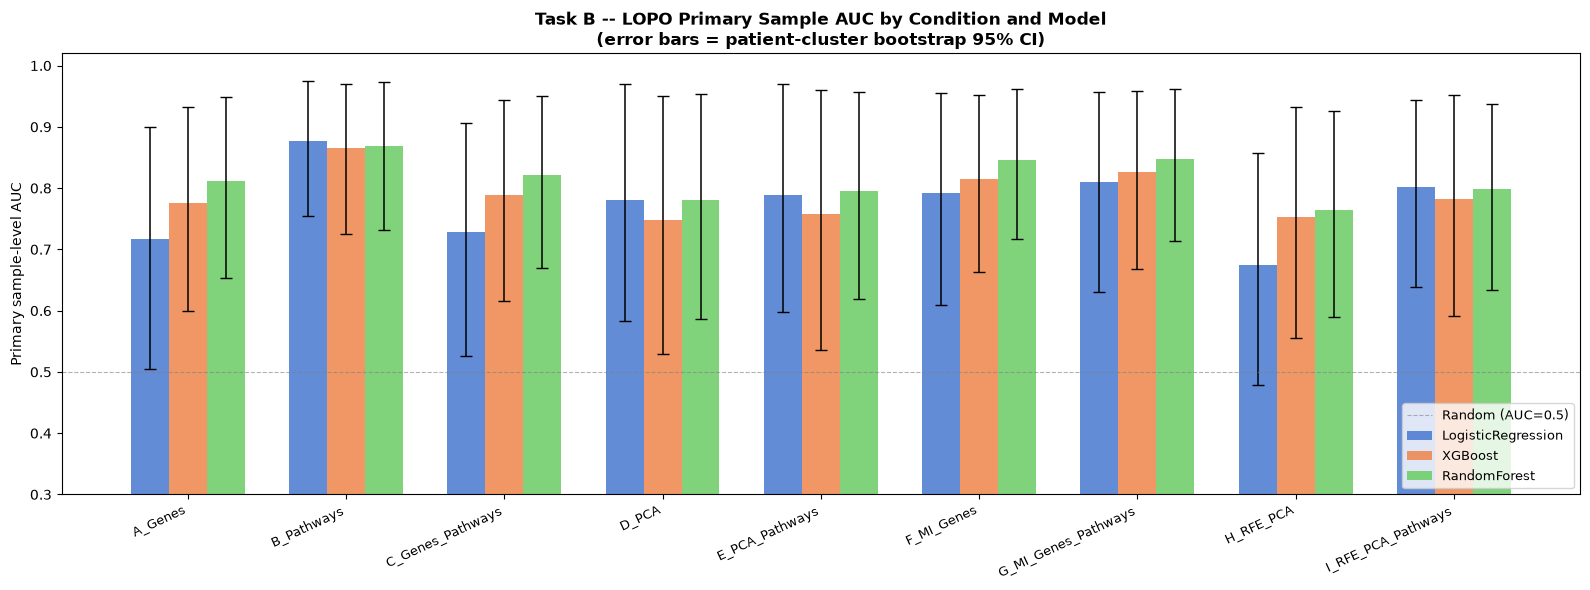

In [17]:
auc_ci = bootstrap_summary_df[bootstrap_summary_df["metric"] == "AUC"].set_index(["Condition", "Model"])

feat_order = CONDITIONS_TO_RUN
model_order = MODELS_TO_RUN
x_base = np.arange(len(feat_order))
width = 0.24
palette = sns.color_palette("muted", len(model_order))

fig, ax = plt.subplots(figsize=(16, 6))
for mi, model_name in enumerate(model_order):
    means, err_lo, err_hi = [], [], []
    for feat_name in feat_order:
        row = auc_ci.loc[(feat_name, model_name)]
        means.append(row["mean"])
        err_lo.append(max(0, row["mean"] - row["ci_lower"]))
        err_hi.append(max(0, row["ci_upper"] - row["mean"]))
    offset = (mi - len(model_order) / 2 + 0.5) * width
    ax.bar(x_base + offset, means, width, label=model_name, color=palette[mi], alpha=0.85)
    ax.errorbar(x_base + offset, means, yerr=[err_lo, err_hi], fmt="none", color="black", capsize=4, linewidth=1.1)

ax.set_xticks(x_base)
ax.set_xticklabels(feat_order, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Primary sample-level AUC")
ax.set_title("Task B -- LOPO Primary Sample AUC by Condition and Model\n(error bars = patient-cluster bootstrap 95% CI)",
             fontweight="bold")
ax.set_ylim(0.3, 1.02)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6, label="Random (AUC=0.5)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_ID}_ablation_auc_with_ci.png", dpi=300)
plt.show()


## Heatmap of Primary Sample AUC (Model x Condition)

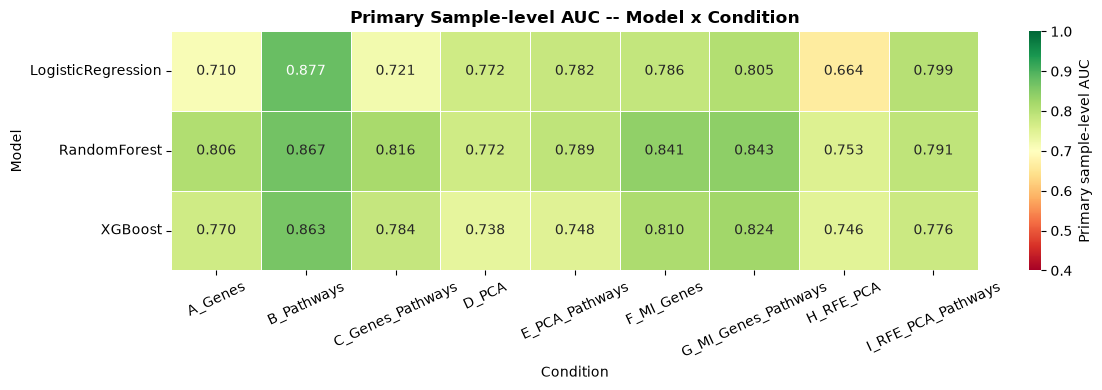

In [18]:
heat_data = summary_df["Primary_Sample_AUC_All"].unstack("Condition")[CONDITIONS_TO_RUN]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heat_data, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.4, vmax=1.0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Primary sample-level AUC"})
ax.set_title("Primary Sample-level AUC -- Model x Condition", fontweight="bold")
ax.tick_params(axis="x", labelrotation=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_ID}_auc_heatmap.png", dpi=300)
plt.show()


## Full Bootstrap AUC Distribution

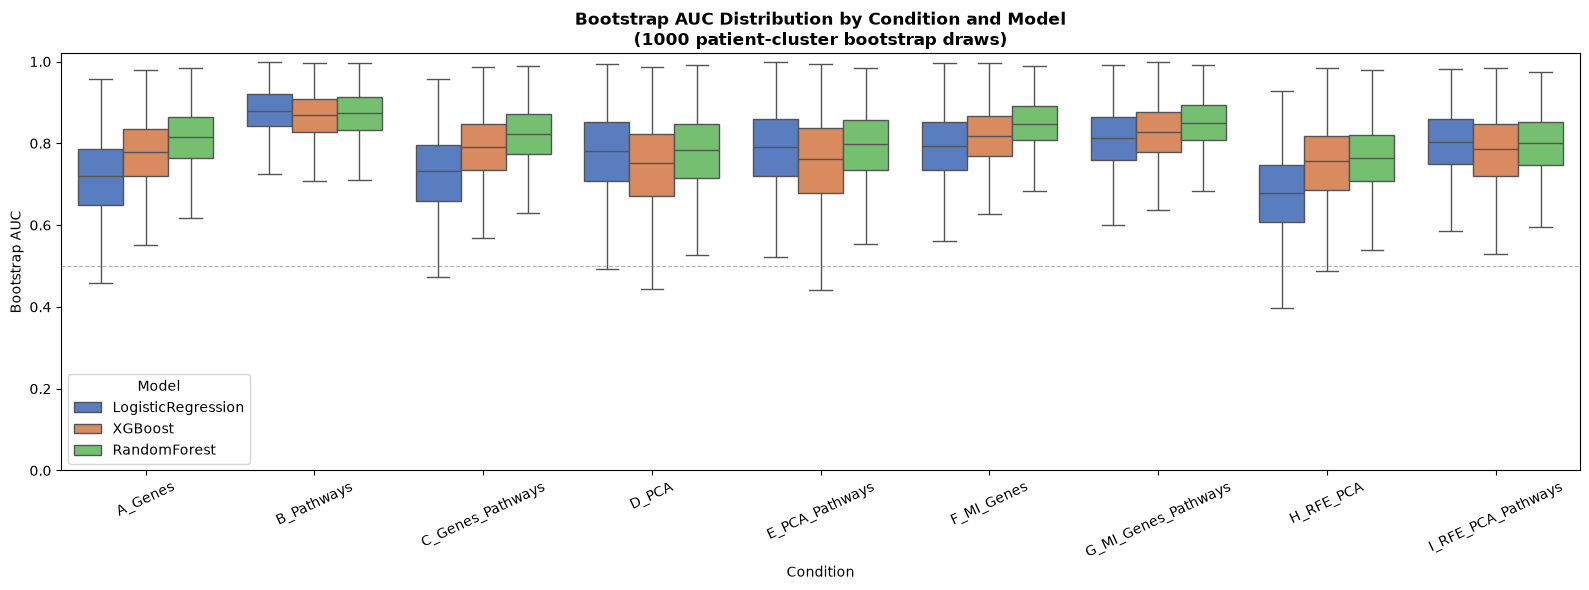

In [19]:
box_rows = []
for (condition_name, model_name), boot_long in bootstrap_results.items():
    auc_draws = boot_long.loc[boot_long["metric"] == "AUC", "value"]
    for v in auc_draws:
        box_rows.append({"Condition": condition_name, "Model": model_name, "Bootstrap AUC": v})
box_df = pd.DataFrame(box_rows)

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=box_df, x="Condition", y="Bootstrap AUC", hue="Model", order=feat_order, hue_order=model_order,
            ax=ax, showfliers=False, palette="muted")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_ylim(0.0, 1.02)
ax.set_title(f"Bootstrap AUC Distribution by Condition and Model\n({BOOTSTRAP_ITERS} patient-cluster bootstrap draws)",
             fontweight="bold")
ax.tick_params(axis="x", labelrotation=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_ID}_bootstrap_auc_boxplot.png", dpi=300)
plt.show()


---
## Best Pipeline Investigation

## Extended Metric Panel, with Uncertainty

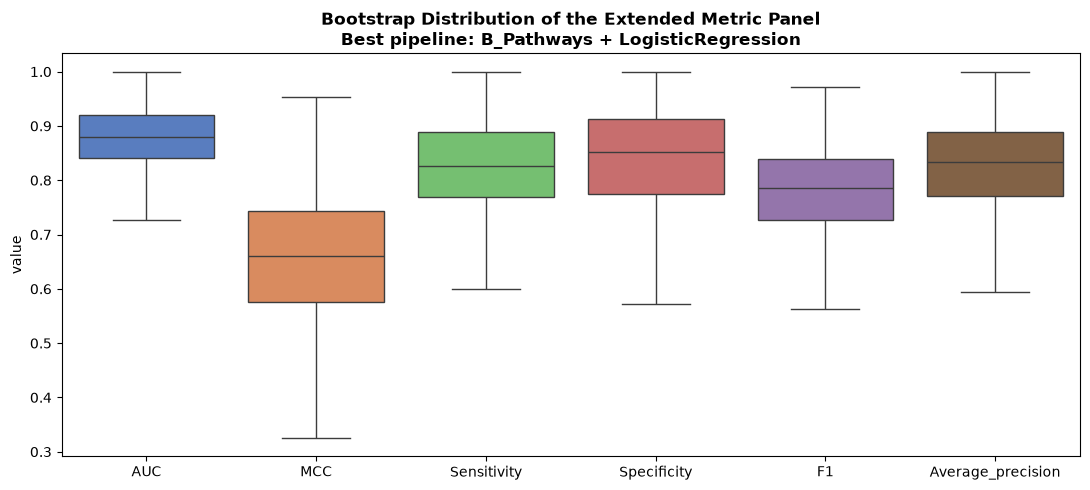

Bootstrap summary for the best pipeline:


,metric,mean,ci_lower,ci_upper,n_valid_draws
0,AUC,0.877003,0.753948,0.974515,1000
1,Average_precision,0.822899,0.622363,0.966046,1000
2,F1,0.777911,0.588235,0.930310,1000
3,MCC,0.656326,0.399538,0.898352,1000
4,Sensitivity,0.824475,0.631414,1.000000,1000
5,Specificity,0.841543,0.653846,1.000000,1000


In [20]:
best_boot_long = bootstrap_results[(best_condition, best_model)]
fig, ax = plt.subplots( figsize=(11, 5))

sns.boxplot(data=best_boot_long,x="metric",y="value",hue="metric",order=list(BOOTSTRAP_METRICS),
            ax=ax,palette="muted",legend=False, showfliers=False)

ax.set_title("Bootstrap Distribution of the Extended Metric Panel\n"
             f"Best pipeline: {best_condition} + {best_model}",fontweight="bold")

ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_ID}_bootstrap_metrics_best_pipeline.png",dpi=300,bbox_inches="tight")
plt.show()


print("Bootstrap summary for the best pipeline:")
display(summarize_bootstrap(best_boot_long))

## Per-Sample Prediction Scores 

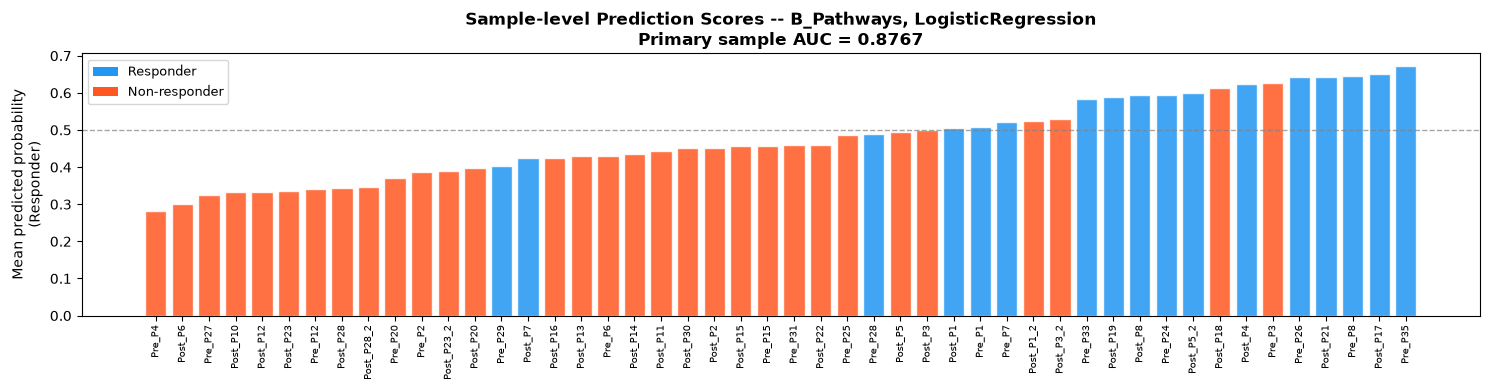

In [22]:
best_sample_predictions = all_sample_predictions[(best_model, best_condition)].copy()
best_sample_predictions["response_label_plot"] = (best_sample_predictions["true_label"].map(
    { 1: "Responder", 0: "Non-responder"}))

res_df = best_sample_predictions.sort_values("sample_score")
colors = {"Responder": "#2196F3","Non-responder": "#FF5722"}
fig, ax = plt.subplots(figsize=(15, 4))

for _, row in res_df.iterrows():
    ax.bar(row["sample_id"], row["sample_score"], color=colors[row["response_label_plot"]],
           alpha=0.85,edgecolor="white")

ax.axhline( 0.5, color="grey",linestyle="--",linewidth=1,alpha=0.7)
ax.set_ylabel("Mean predicted probability\n(Responder)")
ax.set_title(f"Sample-level Prediction Scores -- "
             f"{best_condition}, {best_model}\n"
             f"Primary sample AUC = "
             f"{summary_df.loc[(best_model, best_condition), 'Primary_Sample_AUC_All']:.4f}",
             fontweight="bold")

ax.tick_params(axis="x",labelrotation=90,labelsize=7)
ax.legend( handles=[Patch(facecolor=colors["Responder"],label="Responder"),
                    Patch( facecolor=colors["Non-responder"], label="Non-responder")],
                    fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_ID}_best_pipeline_sample_scores.png",dpi=300,bbox_inches="tight",)
plt.show()


## Score Distribution by True Class 

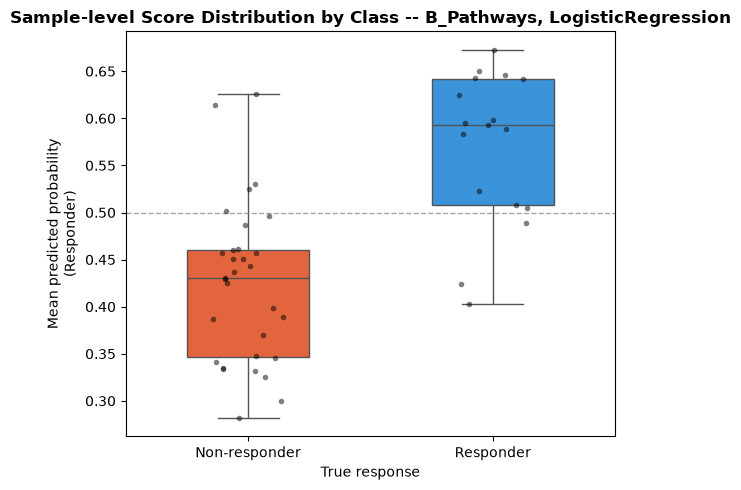

Non-responder: n=31, median=0.431
Responder: n=17, median=0.593


In [23]:
# Comparing sample-level prediction scores between the two true response classes.

class_colors = {"Responder": "#2196F3","Non-responder": "#FF5722",}
class_order = ["Non-responder","Responder",]

fig, ax = plt.subplots( figsize=(6, 5))

sns.boxplot(data=res_df,x="response_label_plot",y="sample_score",hue="response_label_plot",
            order=class_order,hue_order=class_order,ax=ax,palette=class_colors,legend=False,width=0.5)

sns.stripplot(data=res_df,x="response_label_plot",y="sample_score",order=class_order,ax=ax,
              color="black",alpha=0.5,size=4,jitter=0.15)

ax.axhline(0.5,color="grey",linestyle="--",linewidth=1,alpha=0.7)
ax.set_xlabel("True response")
ax.set_ylabel("Mean predicted probability\n(Responder)")
ax.set_title(f"Sample-level Score Distribution by Class -- "f"{best_condition}, {best_model}",fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_ID}_best_pipeline_score_by_class.png",dpi=300,bbox_inches="tight")
plt.show()


# Printing class counts and median prediction scores.

for class_name in class_order:
    class_scores = res_df.loc[res_df["response_label_plot"] == class_name, "sample_score", ]
    print(f"{class_name}: n={len(class_scores)}, median={class_scores.median():.3f}")


---
## Matched ablation contribution analysis


In [24]:
# Comparing matched feature conditions to measure the contribution of adding PROGENy pathways to each base representation.

ABLATION_PAIRS = {"Pathways added to all genes": ("A_Genes","C_Genes_Pathways"),
                  "Pathways added to PCA": ("D_PCA","E_PCA_Pathways"),
                  "Pathways added to MI genes": ("F_MI_Genes","G_MI_Genes_Pathways"),
                  "Pathways added to RFE PCs": ("H_RFE_PCA","I_RFE_PCA_Pathways")}

contribution_metrics = [
    "Primary_Sample_AUC_All","Primary_Sample_Average_precision_All","Primary_Sample_Balanced_accuracy_All",
    "Primary_Sample_Sensitivity_All","Primary_Sample_Specificity_All","Primary_Sample_F1_All",
    "Primary_Sample_MCC_All","Secondary_Sample_AUC_NonMixed","Secondary_Patient_AUC_NonMixed"]

rows = []

for model_name in MODELS_TO_RUN:
    for comparison, (base_condition,extended_condition,) in ABLATION_PAIRS.items():
        base_key = (model_name,base_condition)

        extended_key = ( model_name,extended_condition)

        if ( base_key not in summary_df.index or extended_key not in summary_df.index):
            continue

        row = {"Model": model_name,"Comparison": comparison,"Base": base_condition,"Extended": extended_condition}

        for metric in contribution_metrics:
            if metric in summary_df.columns:
                row[f"Delta_{metric}"] = (summary_df.loc[extended_key,metric] - summary_df.loc[base_key, metric])

        rows.append(row)

contribution_df = (pd.DataFrame(rows).set_index(["Model","Comparison"]).sort_index())

contribution_df.to_csv(RESULTS_DIR / f"{RUN_ID}_matched_ablation_deltas.csv")

display(contribution_df.style.format({column: "{:+.3f}" for column in contribution_df.columns if column.startswith("Delta_")}))

## Pathway contribution to primary sample-level AUC

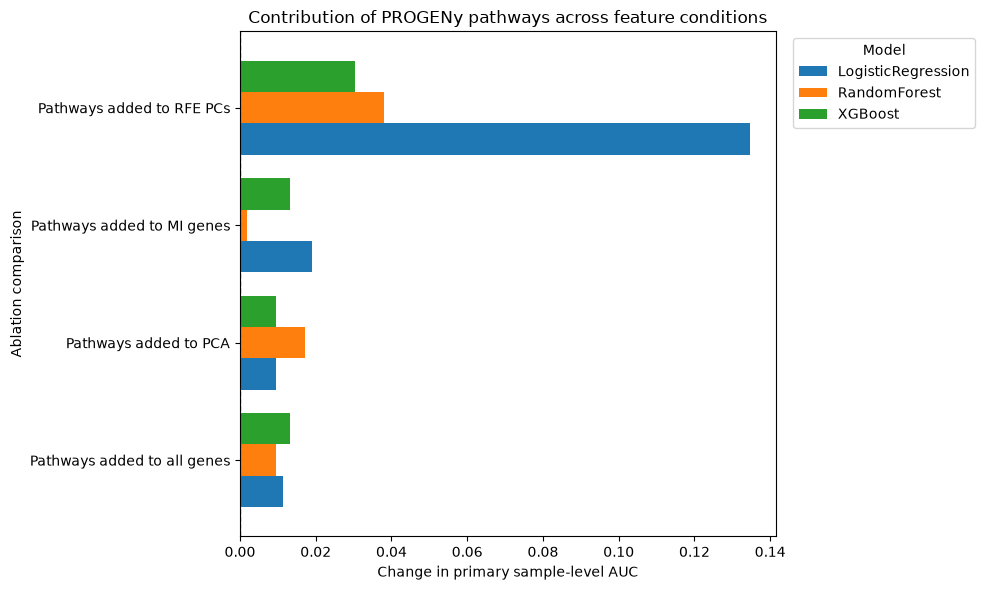

Saved: ..\figures\taskb_shared_preprocessing_patient_score_fixed_v6_pathway_ablation_auc_contribution.png


In [25]:
plot_metric = "Delta_Primary_Sample_AUC_All"

ablation_plot_df = (contribution_df.reset_index().pivot(index="Comparison",columns="Model",values=plot_metric,))
comparison_order = list(ABLATION_PAIRS.keys())
ablation_plot_df = ablation_plot_df.reindex(comparison_order)

ax = ablation_plot_df.plot( kind="barh", figsize=(10, 6),width=0.8,)
ax.axvline(0,linestyle="--",linewidth=1)
ax.set_xlabel( "Change in primary sample-level AUC")
ax.set_ylabel("Ablation comparison")
ax.set_title("Contribution of PROGENy pathways across feature conditions")
ax.legend( title="Model",bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()

ablation_figure_path = (FIGURES_DIR/ f"{RUN_ID}_pathway_ablation_auc_contribution.png")

plt.savefig(ablation_figure_path,dpi=300,bbox_inches="tight")

plt.show()
plt.close()

print("Saved:",ablation_figure_path)

## Genes-only vs pathways-only prediction performance

In [26]:
# Comparing genes-only and pathways-only performance across models.

comparison_conditions = {"Genes only": "A_Genes",
                        "Pathways only": "B_Pathways",}

plot_rows = []

for model_name in MODELS_TO_RUN:

    for display_name, condition_name in comparison_conditions.items():
        key = (model_name,condition_name)
        if key not in summary_df.index:
            continue
        plot_rows.append({"Model": model_name,"Feature set": display_name,
                          "Primary sample AUC": summary_df.loc[key,"Primary_Sample_AUC_All",] })

genes_vs_pathways_df = pd.DataFrame(plot_rows)

display(genes_vs_pathways_df)

,Model,Feature set,Primary sample AUC
0,LogisticRegression,Genes only,0.709677
1,LogisticRegression,Pathways only,0.876660
2,XGBoost,Genes only,0.770398
3,XGBoost,Pathways only,0.863378
4,RandomForest,Genes only,0.806452
5,RandomForest,Pathways only,0.867173


# Plot genes-only vs pathways-only performance across models

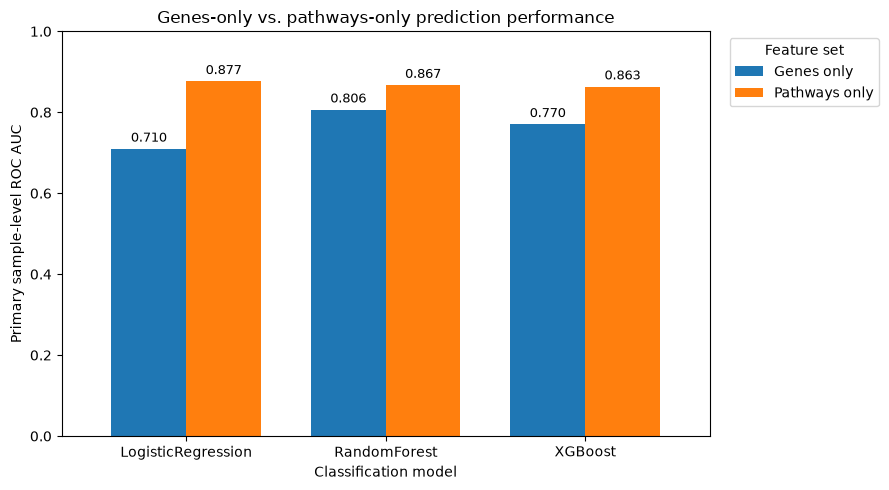

Saved: ..\figures\taskb_shared_preprocessing_patient_score_fixed_v6_genes_vs_pathways_auc.png


In [27]:
genes_vs_pathways_plot_df = genes_vs_pathways_df.pivot(index="Model",columns="Feature set",values="Primary sample AUC")
genes_vs_pathways_plot_df = genes_vs_pathways_plot_df.reindex(columns=["Genes only","Pathways only"])

ax = genes_vs_pathways_plot_df.plot( kind="bar", figsize=(9, 5),width=0.75)
ax.set_title("Genes-only vs. pathways-only prediction performance")
ax.set_xlabel("Classification model")
ax.set_ylabel("Primary sample-level ROC AUC")
ax.set_ylim(0,1)
ax.tick_params(axis="x",rotation=0)


for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=3,fontsize=9 )

ax.legend( title="Feature set", bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()

genes_vs_pathways_figure_path = (FIGURES_DIR/ f"{RUN_ID}_genes_vs_pathways_auc.png")
plt.savefig(genes_vs_pathways_figure_path,dpi=300,bbox_inches="tight",)
plt.show()
plt.close()

print("Saved:", genes_vs_pathways_figure_path)

## Feature-selection stability

In [28]:
# Calculating feature-selection stability across LOPO folds.

selection_stability_tables = {}

for (model_name,condition_name), selected_features in all_selected_features.items():

    if selected_features.empty:
        continue

    n_folds = selected_features["fold"].nunique()

    stability = (selected_features.groupby("feature",observed=True).agg(
        selected_in_folds=("fold","nunique")).assign(selection_frequency=lambda frame:
                                                     frame["selected_in_folds"] / n_folds).sort_values(
                                                         ["selection_frequency","selected_in_folds"],
                                                         ascending=False) )

    result_key = (model_name,condition_name)
    selection_stability_tables[result_key] = stability
    safe_model = (model_name.replace(" ", "_").replace("/", "_"))
    safe_condition = (condition_name.replace(" ", "_").replace("/", "_"))
    stability.to_csv(RESULTS_DIR/ (f"{RUN_ID}_{safe_model}_{safe_condition}_feature_stability.csv"))

    if condition_name in {"F_MI_Genes","G_MI_Genes_Pathways","H_RFE_PCA","I_RFE_PCA_Pathways"}:
        print(f"\n{model_name} | {condition_name}")
        display(stability.head(20))


LogisticRegression | F_MI_Genes


,selected_in_folds,selection_frequency
feature,,
ANXA5,32,1.0
ASF1B,32,1.0
BIRC5,32,1.0
C12orf75,32,1.0
CAPZA2,32,1.0
CCNA2,32,1.0
CDCA3,32,1.0
CDCA8,32,1.0
CDKN2A,32,1.0



XGBoost | F_MI_Genes


,selected_in_folds,selection_frequency
feature,,
ANXA5,32,1.0
ASF1B,32,1.0
BIRC5,32,1.0
C12orf75,32,1.0
CAPZA2,32,1.0
CCNA2,32,1.0
CDCA3,32,1.0
CDCA8,32,1.0
CDKN2A,32,1.0



RandomForest | F_MI_Genes


...

,selected_in_folds,selection_frequency
feature,,
PROGENy_Androgen,32,1.00000
PROGENy_EGFR,32,1.00000
PROGENy_Estrogen,32,1.00000
PROGENy_Hypoxia,32,1.00000
PROGENy_JAK-STAT,32,1.00000
PROGENy_MAPK,32,1.00000
PROGENy_NFkB,32,1.00000
PROGENy_PI3K,32,1.00000
PROGENy_TGFb,32,1.00000



XGBoost | I_RFE_PCA_Pathways


,selected_in_folds,selection_frequency
feature,,
PROGENy_Androgen,32,1.00000
PROGENy_EGFR,32,1.00000
PROGENy_Estrogen,32,1.00000
PROGENy_Hypoxia,32,1.00000
PROGENy_JAK-STAT,32,1.00000
PROGENy_MAPK,32,1.00000
PROGENy_NFkB,32,1.00000
PROGENy_PI3K,32,1.00000
PROGENy_TGFb,32,1.00000



RandomForest | I_RFE_PCA_Pathways


,selected_in_folds,selection_frequency
feature,,
PROGENy_Androgen,32,1.00000
PROGENy_EGFR,32,1.00000
PROGENy_Estrogen,32,1.00000
PROGENy_Hypoxia,32,1.00000
PROGENy_JAK-STAT,32,1.00000
PROGENy_MAPK,32,1.00000
PROGENy_NFkB,32,1.00000
PROGENy_PI3K,32,1.00000
PROGENy_TGFb,32,1.00000
